In [1]:
import os
os.listdir('.')

['.config',
 '.kernel_llm_logs_1.txt',
 'memory',
 '.prompts',
 'pair_gap_histogram.csv']

In [2]:
import urllib.request
# Try Odlyzko's zeros1 file - first 100,000 zeros
url = "https://www-users.cse.umn.edu/~odlyzko/zeta_tables/zeros1"
import os, time
t0 = time.time()
try:
    urllib.request.urlretrieve(url, "zeros1.txt")
    print("downloaded zeros1 size:", os.path.getsize("zeros1.txt"), "in", time.time()-t0, "s")
except Exception as e:
    print("err:", e)

downloaded zeros1 size: 1800000 in 0.7258946895599365 s


In [3]:
with open("zeros1.txt") as f:
    for i in range(3):
        print(repr(f.readline()))

'     14.134725142\n'
'     21.022039639\n'
'     25.010857580\n'


In [4]:
# Try to also get a million zeros — Odlyzko hosts zeros2 (zeros 10^5+1 to 2*10^5), but only 100k each
# Better: LMFDB has bulk files. Let's try a known location for the first 1M zeros.
# Odlyzko has zeros1 (1..10^5). For 1M zeros, there are larger downloadable files. Let me check.
import urllib.request
for name in ["zeros2", "zeros3", "zeros4", "zeros5", "zeros6"]:
    try:
        url = f"https://www-users.cse.umn.edu/~odlyzko/zeta_tables/{name}"
        req = urllib.request.Request(url, method='HEAD')
        with urllib.request.urlopen(req, timeout=10) as r:
            print(name, r.status, r.headers.get("Content-Length"))
    except Exception as e:
        print(name, "err", e)

zeros2 200 105979
zeros3 200 180287


zeros4 200 160319
zeros5 200 170318


zeros6 200 36018936


In [5]:
# zeros6 is 36MB - likely contains 2*10^6 zeros starting from a high point. 
# zeros2-5 may be far apart in n. Let's check actual content briefly.
import urllib.request
url = "https://www-users.cse.umn.edu/~odlyzko/zeta_tables/zeros2"
urllib.request.urlretrieve(url, "zeros2.txt")
with open("zeros2.txt") as f:
    head = [f.readline() for _ in range(3)]
print(head)
# tail
import subprocess
print(subprocess.check_output(["tail","-3","zeros2.txt"]).decode())
print("lines:", sum(1 for _ in open("zeros2.txt")))

['\n', '  14.134725141734693790457251983562470270784257115699243175685567460149\n', ' 9634298092567649490103931715610127792029715487974367661426914698822545\n']
 3258478241372746723689425816666668066628696207830016767930784349540940
 46048236402952743224761478361793490446024555390
  

lines: 1601


In [6]:
# zeros2 is high-precision (single zero across multiple lines). Not what we need for 1M zeros.
# Let me check LMFDB or a Github copy. First, check size of zeros6:
# 36 MB / ~36 bytes/line ≈ 1M lines. Let me sample.
import urllib.request
url = "https://www-users.cse.umn.edu/~odlyzko/zeta_tables/zeros6"
# Get just first part
req = urllib.request.Request(url, headers={"Range": "bytes=0-2000"})
with urllib.request.urlopen(req) as r:
    print(r.read().decode()[:2000])

     14.134725142
     21.022039639
     25.010857580
     30.424876126
     32.935061588
     37.586178159
     40.918719012
     43.327073281
     48.005150881
     49.773832478
     52.970321478
     56.446247697
     59.347044003
     60.831778525
     65.112544048
     67.079810529
     69.546401711
     72.067157674
     75.704690699
     77.144840069
     79.337375020
     82.910380854
     84.735492981
     87.425274613
     88.809111208
     92.491899271
     94.651344041
     95.870634228
     98.831194218
    101.317851006
    103.725538040
    105.446623052
    107.168611184
    111.029535543
    111.874659177
    114.320220915
    116.226680321
    118.790782866
    121.370125002
    122.946829294
    124.256818554
    127.516683880
    129.578704200
    131.087688531
    133.497737203
    134.756509753
    138.116042055
    139.736208952
    141.123707404
    143.111845808
    146.000982487
    147.422765343
    150.053520421
    150.925257612
    153.024693811
    156.11

In [7]:
# Great - zeros6 is in the same format. Let's download it.
import urllib.request, time, os
t0 = time.time()
urllib.request.urlretrieve("https://www-users.cse.umn.edu/~odlyzko/zeta_tables/zeros6", "zeros6.txt")
print("downloaded", os.path.getsize("zeros6.txt"), "in", time.time()-t0)
print("lines:", sum(1 for _ in open("zeros6.txt")))

downloaded 36018936 in 1.718862533569336
lines: 2001052


In [8]:
# 2,001,052 lines. Header/footer? Check end
import subprocess
print(subprocess.check_output(["head","-3","zeros6.txt"]).decode())
print("---")
print(subprocess.check_output(["tail","-3","zeros6.txt"]).decode())

     14.134725142
     21.022039639
     25.010857580

---
1132489.585214591
1132490.165304883
1132490.658714411



In [9]:
import numpy as np
zeros = np.loadtxt("zeros6.txt")
print(zeros.shape, zeros[0], zeros[-1])
# Take first 1,000,000
zeros = zeros[:1_000_000]
print("first 1M:", zeros.shape, zeros[0], zeros[-1])

(2001052,) 14.134725142 1132490.658714411
first 1M: (1000000,) 14.134725142 600269.677012445


In [10]:
# Great. The standard procedure for analyzing local correlations is to "unfold" the zeros
# so the mean spacing is 1. The unfolding map is φ(γ) = (γ/(2π)) * log(γ/(2πe)) + 7/8 + ...
# For local statistics this is essential.

# Unfold using the leading asymptotic for the number of zeros up to height T:
# N(T) ≈ (T/2π) log(T/2πe) + 7/8
import numpy as np
def unfold(g):
    return (g/(2*np.pi)) * np.log(g/(2*np.pi*np.e)) + 7/8

xs = unfold(zeros)
print("unfolded range:", xs[0], xs[-1], "len", len(xs))
# Check normalized spacings near 1
gaps = np.diff(xs)
print("mean gap:", gaps.mean(), "std:", gaps.std(), "min/max:", gaps.min(), gaps.max())

unfolded range: 0.4492778727775523 999999.5712946195 len 1000000
mean gap: 1.0000001220168688 std: 0.40625489308038976 min/max: 0.009695067652501166 3.2142617439385504


In [11]:
# Excellent: mean gap ~1 after unfolding.
# 
# Strategy:
# 1) Distribution of consecutive-gap ratio r_n = (γ_{n+2}-γ_{n+1})/(γ_{n+1}-γ_n) (or unfolded equivalent).
#    For GUE there is a known Atas-Bogomolny-Giraud-Roux (ABGR) distribution.
#    Note: ratio is scale-free so unfolding cancels. Compare to GUE 3x3 surmise: 
#        P(r) = (81*sqrt(3)/(4*pi)) * (r + r^2)^2 / (1 + r + r^2)^4
# 2) Histogram of (γ_c - γ_b) - (γ_b - γ_a) for consecutive triples (in unfolded coords), centered at 0.
# 3) Compare to a shuffled null model that preserves gap distribution but breaks higher-order correlations.

# Plan: KS test on r_n distribution vs GUE surmise; chi-square comparing observed counts.
# For consecutive-triplet AP residual, use unfolded coords; compare observed histogram to shuffled null.

# 1) Ratio distribution
g = np.diff(zeros)  # raw gaps; ratio is scale-invariant locally
r = g[1:] / g[:-1]
print("r count:", len(r), "min/max:", r.min(), r.max(), "median:", np.median(r))

# ABGR/surmise for GUE (β=2):
def P_GUE_ratio(r):
    return (81*np.sqrt(3)/(4*np.pi)) * (r + r*r)**2 / (1 + r + r*r)**4

# Visual histogram
import numpy as np
bins = np.linspace(0, 5, 251)
counts, edges = np.histogram(r, bins=bins)
centers = 0.5*(edges[:-1]+edges[1:])
widths = np.diff(edges)
density = counts / (len(r) * widths)
expected_density = P_GUE_ratio(centers)
# Show some
for i in [0,10,50,100,150,200]:
    print(f"r≈{centers[i]:.3f}  obs_density={density[i]:.4f}  GUE_pred={expected_density[i]:.4f}")

r count: 999998 min/max: 0.008156073850472314 131.10416776160355 median: 1.0004821690938634
r≈0.010  obs_density=0.0015  GUE_pred=0.0011
r≈0.210  obs_density=0.2751  GUE_pred=0.2914
r≈1.010  obs_density=0.5550  GUE_pred=0.5458
r≈2.010  obs_density=0.1667  GUE_pred=0.1654
r≈3.010  obs_density=0.0523  GUE_pred=0.0557
r≈4.010  obs_density=0.0211  GUE_pred=0.0228


In [12]:
# Compute expected counts via integrated P(r) over each bin (use midpoint or quad). Bins are narrow (0.02), midpoint is fine.
from scipy.integrate import quad
# Integrate over bins to get expected probability mass per bin
exp_prob = np.array([quad(P_GUE_ratio, edges[i], edges[i+1], limit=50)[0] for i in range(len(centers))])
# Probability mass beyond r=5
tail = quad(P_GUE_ratio, 5, np.inf, limit=200)[0]
print("tail prob (r>5):", tail, "obs frac (r>5):", (r>5).sum()/len(r))
exp_counts = exp_prob * len(r)
obs_counts = counts.astype(float)

# Chi-square (only bins with expected >=5)
mask = exp_counts >= 5
chi2 = np.sum((obs_counts[mask]-exp_counts[mask])**2 / exp_counts[mask])
dof = mask.sum() - 1
from scipy.stats import chi2 as chi2dist
p_val = 1 - chi2dist.cdf(chi2, dof)
print(f"chi-sq = {chi2:.2f}, dof={dof}, p={p_val:.3e}")

# Standardized residuals
resid = (obs_counts - exp_counts) / np.sqrt(exp_counts + 1e-12)
# Bonferroni threshold (two-sided z) over ~250 bins
from scipy.stats import norm
alpha = 0.05
z_crit = norm.ppf(1 - alpha/(2*len(centers)))
print("Bonferroni z critical (~):", z_crit)
print("max |z|:", np.max(np.abs(resid[mask])), "at r =", centers[mask][np.argmax(np.abs(resid[mask]))])
sig_idx = np.where(np.abs(resid)>z_crit)[0]
print("# bins exceeding Bonferroni z:", len(sig_idx))
for i in sig_idx[:20]:
    print(f"  r={centers[i]:.3f}  obs={obs_counts[i]:.0f}  exp={exp_counts[i]:.1f}  z={resid[i]:.2f}")

tail prob (r>5): 0.02088747307879578 obs frac (r>5): 0.019041038082076165


chi-sq = 721.11, dof=249, p=0.000e+00
Bonferroni z critical (~): 3.719016485455709
max |z|: 6.379471710404219 at r = 0.13
# bins exceeding Bonferroni z: 10
  r=0.090  obs=1328  exp=1481.3  z=-3.98
  r=0.110  obs=1884  exp=2102.4  z=-4.76
  r=0.130  obs=2450  exp=2786.8  z=-6.38
  r=0.150  obs=3294  exp=3516.8  z=-3.76
  r=0.170  obs=3873  exp=4276.3  z=-6.17
  r=0.190  obs=4722  exp=5050.9  z=-4.63
  r=0.210  obs=5501  exp=5828.0  z=-4.28
  r=0.230  obs=6116  exp=6596.4  z=-5.92
  r=0.270  obs=7727  exp=8071.5  z=-3.83
  r=0.690  obs=14246  exp=13791.0  z=3.87


In [13]:
# Important: P_GUE_ratio is the 3x3 ABGR SURMISE — an approximation, not exact for large N GUE.
# Deviations from the surmise are known. To test whether the observed deviations represent
# *3-point correlations beyond what GUE predicts*, we need a more careful null.
#
# Best approach: compare to a "shuffled" null where pair-level statistics are preserved
# but ordering correlations are broken. Specifically: take the multiset of gaps {g_n}, 
# randomly permute them, and compute r distribution. This is the "pair-level" null with the
# same gap distribution but no 3-pt correlation. Compare observed to this.
#
# This is the standard test: if observed != shuffled gaps, then there's structure beyond
# the pair distribution.

rng = np.random.default_rng(42)
g_shuffled = g.copy()
rng.shuffle(g_shuffled)
r_shuf = g_shuffled[1:] / g_shuffled[:-1]
# Histogram on same bins
counts_shuf, _ = np.histogram(r_shuf, bins=bins)

# Compare observed vs shuffled — chi-square / standardized differences (both ~10^6 samples)
# For each bin: observed N1, shuffled N2; null hypothesis: same underlying probability.
# Use a two-sample test on counts (poisson approx): z = (O - S) / sqrt(O + S)
diff_z = (obs_counts - counts_shuf) / np.sqrt(obs_counts + counts_shuf + 1e-12)
mask2 = (obs_counts + counts_shuf) >= 20
n_bins = mask2.sum()
print("n_bins:", n_bins)
z_crit2 = norm.ppf(1 - 0.05/(2*n_bins))
print("Bonferroni z crit:", z_crit2)
print("max |z|:", np.max(np.abs(diff_z[mask2])))
sig2 = np.where((np.abs(diff_z) > z_crit2) & mask2)[0]
print("# significant bins:", len(sig2))
for i in sig2:
    print(f"  r={centers[i]:.3f}  obs={obs_counts[i]:.0f}  shuf={counts_shuf[i]:.0f}  z={diff_z[i]:.2f}")
# Overall chi-square test
mask3 = (obs_counts + counts_shuf) >= 10
chi2_pair = np.sum((obs_counts[mask3] - counts_shuf[mask3])**2 / (obs_counts[mask3] + counts_shuf[mask3]))
print(f"\nTwo-sample chi-square = {chi2_pair:.2f}, dof={mask3.sum()-1}, p={1-chi2dist.cdf(chi2_pair, mask3.sum()-1):.3e}")

n_bins: 250
Bonferroni z crit: 3.719016485455709
max |z|: 20.19414092718533
# significant bins: 181
  r=0.030  obs=174  shuf=97  z=4.68
  r=0.050  obs=438  shuf=235  z=7.83
  r=0.070  obs=853  shuf=460  z=10.85
  r=0.090  obs=1328  shuf=747  z=12.75
  r=0.110  obs=1884  shuf=1034  z=15.74
  r=0.130  obs=2450  shuf=1499  z=15.13
  r=0.150  obs=3294  shuf=1976  z=18.16
  r=0.170  obs=3873  shuf=2480  z=17.48
  r=0.190  obs=4722  shuf=3055  z=18.90
  r=0.210  obs=5501  shuf=3672  z=19.10
  r=0.230  obs=6116  shuf=4235  z=18.49
  r=0.250  obs=7117  shuf=4903  z=20.19
  r=0.270  obs=7727  shuf=5622  z=18.22
  r=0.290  obs=8487  shuf=6313  z=17.87
  r=0.310  obs=9202  shuf=7143  z=16.11
  r=0.330  obs=9672  shuf=7767  z=14.43
  r=0.350  obs=10343  shuf=8507  z=13.37
  r=0.370  obs=11064  shuf=9160  z=13.39
  r=0.390  obs=11506  shuf=9859  z=11.27
  r=0.410  obs=11955  shuf=10596  z=9.05
  r=0.430  obs=12384  shuf=11162  z=7.96
  r=0.450  obs=12670  shuf=11625  z=6.70
  r=0.470  obs=13074  sh

In [14]:
# Huge differences vs shuffled gaps. BUT — this is expected:
# The shuffled null destroys ALL ordering correlations including 2-point correlations.
# It would show deviation even if only 2-point GUE correlations are present (because GUE
# has level repulsion — neighboring gaps are correlated even at the pair level).
#
# So this comparison only confirms that ordering matters — it's not specific to "3-point" correlations.
# 
# For a CLEANER 3-point test, we need a null that preserves the 2-point correlation structure
# of GUE but breaks 3-point structure. Two approaches:
#
# (A) Pair-of-gaps shuffle: keep pairs of consecutive gaps (g_n, g_{n+1}) intact (this preserves
#     the joint 2-point distribution), but break the chain by randomly permuting pairs. Doesn't help
#     because triples (g_n,g_{n+1},g_{n+2}) share gaps so 3-point info still lives in there.
#
# (B) GUE 3x3 surmise: The ABGR distribution P_GUE_ratio(r) is the exact result for a GUE 3x3 matrix.
#     The deviation of the observed r distribution from the surmise IS the deviation from the
#     leading-order 3-point GUE behavior. In fact, for large GUE N→∞, P(r) is very close to (but
#     not exactly equal to) the 3x3 surmise. The chi-sq=721 deviations we found (~6σ around r~0.15-0.25)
#     could be either:
#     (i) statistically real 3-point deviations from infinite-N GUE
#     (ii) the systematic difference between the 3x3 surmise and the true large-N GUE answer.
#
# Let's check what the literature says about the surmise accuracy. Atas-Bogomolny-Giraud-Roux (2013)
# noted the surmise is extremely accurate but not exact. For β=2 the relative error is small.
#
# Let's also do a complementary test: triple-gap residual histogram (γ_c-γ_b)-(γ_b-γ_a) on unfolded zeros,
# i.e., difference of consecutive UNFOLDED gaps. Compare to a Monte Carlo GUE simulation.

# First: histogram of consecutive unfolded-gap differences
sg = np.diff(xs)  # unfolded gaps, mean 1
d = sg[1:] - sg[:-1]  # consecutive gap differences (proxy for AP residual)
print("d count:", len(d), "mean:", d.mean(), "std:", d.std())
# Histogram around 0
bins_d = np.linspace(-2, 2, 401)
counts_d, edges_d = np.histogram(d, bins=bins_d)
centers_d = 0.5*(edges_d[:-1]+edges_d[1:])
# Compare to "shuffled gaps" null (preserves gap distribution only)
sg_shuf = sg.copy(); rng.shuffle(sg_shuf)
d_shuf = sg_shuf[1:] - sg_shuf[:-1]
counts_d_shuf, _ = np.histogram(d_shuf, bins=bins_d)
# This will show 3-pt structure obviously different from gap-shuffled
z_d = (counts_d - counts_d_shuf) / np.sqrt(counts_d + counts_d_shuf + 1e-12)
mask_d = (counts_d + counts_d_shuf) >= 30
zcrit_d = norm.ppf(1 - 0.05/(2*mask_d.sum()))
print("Bonferroni zcrit:", zcrit_d, "max |z|:", np.max(np.abs(z_d[mask_d])))
# Near zero (AP-like triples):
near0 = (np.abs(centers_d) < 0.1)
print("\nNear-zero excess (|d|<0.1):", counts_d[near0].sum(), "vs shuffled:", counts_d_shuf[near0].sum())
print("ratio:", counts_d[near0].sum()/counts_d_shuf[near0].sum())

d count: 999998 mean: 1.048300434246896e-07 std: 0.6676555689571958
Bonferroni zcrit: 3.8361069311760336 max |z|: 12.534033111653047

Near-zero excess (|d|<0.1): 116251 vs shuffled: 139926
ratio: 0.8308034246673242


In [15]:
# Interesting: in observed data, there's actually a *DEPLETION* near d=0 (ratio 0.83)
# compared to a gap-shuffled null. This is OPPOSITE to the hypothesis: rather than an
# EXCESS of approximate APs, there is a DEFICIT. This reflects spectral rigidity.
# 
# But again, the gap-shuffled null is too crude — it breaks 2-point correlations too.
#
# To properly test for "3-point structure beyond GUE", we should compare to a Monte Carlo
# GUE simulation. Let me do this carefully.

# Generate GUE matrix eigenvalues — equivalent number of eigenvalues to get 1M samples.
# A GUE matrix of size N gives N eigenvalues. Unfolding using semicircle density.
# Simulating N=10^6 GUE eigenvalues is expensive (O(N^3) diagonalization).
# Strategy: simulate many smaller GUE matrices (e.g. N=500, do 2000 of them) -> 10^6 eigenvalues.

# This is computationally feasible. Let me try N=400, 2500 trials, focusing on bulk eigenvalues.
import time
def gue_eigs(N, rng):
    A = rng.standard_normal((N,N)) + 1j*rng.standard_normal((N,N))
    A = (A + A.conj().T)/2  # GUE, with variance ~1 on diagonal entries
    # Normalize: standard GUE has off-diagonal var=1, diagonal var=2 typically
    return np.linalg.eigvalsh(A)

# Quick test
rng2 = np.random.default_rng(0)
t0=time.time()
e = gue_eigs(400, rng2)
print("N=400 took", time.time()-t0, "s")
# We need ~1M eigenvalues; only keep central ~60% (bulk) per matrix; 
# 400*0.6 = 240 bulk per matrix; need ~4200 matrices -> ~4200 sec at 1 sec each? Let's time better.
t0=time.time()
for _ in range(10):
    _ = gue_eigs(400, rng2)
print("avg N=400:", (time.time()-t0)/10)

N=400 took 0.05606389045715332 s


avg N=400: 0.04144597053527832


In [16]:
# 0.04s per matrix at N=400. Each gives ~240 bulk eigenvalues.
# Need ~1M -> ~4200 matrices -> ~170s. Doable.
# Actually let's use larger N=800 for fewer matrices and better unfolding.
import time
rng2 = np.random.default_rng(1)
t0=time.time()
for _ in range(5):
    _ = gue_eigs(800, rng2)
print("avg N=800:", (time.time()-t0)/5)

avg N=800: 0.13257842063903807


In [17]:
# 0.13s per N=800 matrix; need 1M/(800*0.6)≈2080 matrices -> ~270s. 
# Let's go with N=600, keeping middle 60% (360 eigs/matrix), need ~2800 matrices.
import time
rng2 = np.random.default_rng(2)
t0=time.time()
for _ in range(5):
    _ = gue_eigs(600, rng2)
dt = (time.time()-t0)/5
print("avg N=600:", dt, "estimated total:", dt * 2800, "s")

avg N=600: 0.08984479904174805 estimated total: 251.56543731689456 s


In [18]:
# Run the GUE Monte Carlo
import time
import numpy as np
rng2 = np.random.default_rng(42)
N = 600
n_matrices = 2800

# We'll collect:
# - ratios r = (gap_{n+1}/gap_n) from BULK eigenvalues (after unfolding to mean spacing 1)
# - differences d = gap_{n+1} - gap_n  (unfolded)
all_r = []
all_d = []
t0 = time.time()
for i in range(n_matrices):
    A = rng2.standard_normal((N,N)) + 1j*rng2.standard_normal((N,N))
    A = (A + A.conj().T)/2
    eig = np.linalg.eigvalsh(A)
    # Wigner semicircle radius for our normalization: 
    # H = (A+A*)/2 with A_ij ~ CN(0,1) iid. Variance of off-diag = 1; diag = 2.
    # Semicircle radius R = 2*sqrt(N) approximately for variance=1 per entry (standard GUE).
    # We'll unfold empirically using semicircle CDF.
    # Bulk = middle 60%
    lo = int(0.20*N); hi = int(0.80*N)
    bulk = eig[lo:hi]
    # Local unfolding via the smooth semicircle CDF:
    # ρ(x) = (1/(2π σ²)) * sqrt(4Nσ² - x²) where σ²=variance of off-diagonal (=1 here)
    # Effective σ²: off-diagonal variance is 1 (since real+imag each ~N(0,1) gives |z|^2 var 2; halved by (A+A*)/2... 
    # Actually we want to just unfold numerically. Easiest: use rank/normalize per matrix.
    # For local spacing statistics (ratios), unfolding via local mean spacing works.
    # 
    # Simpler & correct: ratios are invariant to local rescaling -- the GUE ratio distribution 
    # in the bulk is the same whether unfolded or not (since it cancels in the ratio).
    g_bulk = np.diff(bulk)
    r_b = g_bulk[1:] / g_bulk[:-1]
    all_r.append(r_b)
    # For d (gap differences), we need to unfold first. Use a local rescaling: divide gaps
    # by the local mean spacing. For mid-bulk eigenvalues, use the analytical semicircle density.
    # Semicircle: ρ(x) = (1/(2π)) sqrt(4N - x²/σ²) ... 
    # Simpler approach: rescale each gap by the local mean gap (estimated from neighboring 20 gaps).
    # For a quick test: use the median gap in bulk as the unit (decent for the central region).
    # Actually proper: locally normalize. Use the mean gap.
    # The bulk gap distribution shifts a bit with position; to be careful let's just unfold via semicircle.
    # Standard semicircle: eigs are in [-2√N σ, 2√N σ]; we don't know σ exactly so let's measure.
    # Use the empirical CDF unfolding:
    # x_i_unfolded = N * F(x_i) where F is CDF of empirical eigenvalues. But this trivializes ratios.
    # Better: parametric semicircle unfolding. 
    # Measure σ² by variance of off-diagonals (we set them to var=1). So R = 2√N.
    R = 2*np.sqrt(N)
    # Semicircle CDF: F(x) = (1/(2π))[x*sqrt(R^2-x^2) + R^2 * arcsin(x/R)] / R^2 + 0.5
    # Multiply by N to get unfolded positions
    def unfold_sc(x, N, R):
        x = np.clip(x, -R+1e-9, R-1e-9)
        return N * ((x*np.sqrt(R*R - x*x) + R*R*np.arcsin(x/R))/(np.pi*R*R) + 0.5)
    bulk_uf = unfold_sc(bulk, N, R)
    g_uf = np.diff(bulk_uf)
    d_b = g_uf[1:] - g_uf[:-1]
    all_d.append(d_b)
    if i % 500 == 0 and i>0:
        print(f"  {i}/{n_matrices}, elapsed {time.time()-t0:.0f}s")

r_gue = np.concatenate(all_r)
d_gue = np.concatenate(all_d)
print(f"\nGUE r samples: {len(r_gue)}, d samples: {len(d_gue)}")
print(f"GUE r median: {np.median(r_gue):.4f}, mean gap difference: {d_gue.mean():.4f}, std: {d_gue.std():.4f}")
print(f"Total time: {time.time()-t0:.0f}s")

  500/2800, elapsed 37s


  1000/2800, elapsed 73s


  1500/2800, elapsed 111s


  2000/2800, elapsed 147s


  2500/2800, elapsed 184s



GUE r samples: 1002400, d samples: 1002400
GUE r median: 0.9997, mean gap difference: -0.0000, std: 0.6867
Total time: 206s


In [19]:
# Now compare observed (Riemann zeros) to GUE Monte Carlo.
# Both samples ~1M -> can detect very fine deviations.

# --- Ratio distribution comparison ---
bins_r = np.linspace(0, 5, 251)
obs_r_counts, edges_r = np.histogram(r, bins=bins_r)
gue_r_counts, _ = np.histogram(r_gue, bins=bins_r)
centers_r = 0.5*(edges_r[:-1]+edges_r[1:])

# Normalize both to same total in fitting range
N_obs = obs_r_counts.sum()
N_gue = gue_r_counts.sum()
print("obs in range:", N_obs, "gue in range:", N_gue)

# Two-sample chi-square (Pearson on contingency-style)
# Expected under H0 (same distribution): combine; expected_i = (N_obs+N_gue)*p_i, etc.
total = obs_r_counts + gue_r_counts
mask = total >= 20
# proper two-sample chi-sq:
# X² = sum_i [ (O_obs_i - E_obs_i)^2/E_obs_i + (O_gue_i - E_gue_i)^2/E_gue_i ]
E_obs = total * (N_obs/(N_obs+N_gue))
E_gue = total * (N_gue/(N_obs+N_gue))
chi2_r = np.sum( (obs_r_counts[mask]-E_obs[mask])**2/E_obs[mask] + (gue_r_counts[mask]-E_gue[mask])**2/E_gue[mask] )
dof_r = mask.sum()-1
p_r = 1 - chi2dist.cdf(chi2_r, dof_r)
print(f"\n[Ratio] two-sample chi² = {chi2_r:.1f}, dof = {dof_r}, p = {p_r:.3e}")

# Per-bin z-scores
# z_i = (O_obs_i - E_obs_i) / sqrt(E_obs_i * N_gue/(N_obs+N_gue))   (proper variance for binomial)
var_i = total * (N_obs*N_gue)/(N_obs+N_gue)**2
zr = (obs_r_counts - E_obs) / np.sqrt(var_i + 1e-12)
zcrit_r = norm.ppf(1 - 0.05/(2*mask.sum()))
print("Bonferroni z critical:", zcrit_r, "max |z|:", np.max(np.abs(zr[mask])))
sig = np.where((np.abs(zr) > zcrit_r) & mask)[0]
print(f"# significant bins: {len(sig)}")
# Top deviations
order = np.argsort(-np.abs(zr*mask))
print("\nTop |z| deviations (obs - gue):")
for i in order[:15]:
    print(f"  r={centers_r[i]:.3f}  obs={obs_r_counts[i]}  gue={gue_r_counts[i]}  z={zr[i]:.2f}")

obs in range: 980957 gue in range: 980598

[Ratio] two-sample chi² = 798.6, dof = 249, p = 0.000e+00
Bonferroni z critical: 3.719016485455709 max |z|: 6.526605113720729
# significant bins: 12

Top |z| deviations (obs - gue):
  r=0.230  obs=6116  gue=6857  z=-6.53
  r=0.130  obs=2450  gue=2875  z=-5.84
  r=0.170  obs=3873  gue=4319  z=-4.94
  r=0.150  obs=3294  gue=3703  z=-4.90
  r=0.330  obs=9672  gue=10346  z=-4.79
  r=0.210  obs=5501  gue=6008  z=-4.75
  r=0.110  obs=1884  gue=2185  z=-4.73
  r=0.250  obs=7117  gue=7644  z=-4.36
  r=0.190  obs=4722  gue=5143  z=-4.26
  r=0.270  obs=7727  gue=8236  z=-4.05
  r=0.810  obs=13264  gue=12617  z=3.99
  r=0.090  obs=1328  gue=1532  z=-3.82
  r=0.070  obs=853  gue=1006  z=-3.56
  r=1.050  obs=10680  gue=10183  z=3.41
  r=3.530  obs=604  gue=726  z=-3.35


In [20]:
# Notable: At small r (0.1 - 0.35), observed has FEWER triples than GUE.
# This means the Riemann zeros have somewhat *more* spectral rigidity at the 3-point level
# than finite GUE matrices of size N=600.
#
# Caveat: Finite GUE has finite-N corrections. The Riemann zeros are essentially the N→∞ limit
# in terms of locally-unfolded statistics. The 3x3 ABGR surmise differs from large-N GUE,
# and N=600 still has finite-N corrections too.
#
# Let me try larger N to be sure: N=1000 with fewer matrices.
# This will reduce finite-N corrections.

import time
rng3 = np.random.default_rng(123)
N2 = 1000
n_m2 = 600  # Keep middle 60% -> 600 bulk eigs/matrix; 600*600 = 360K eigs
all_r2 = []
all_d2 = []
t0=time.time()
for i in range(n_m2):
    A = rng3.standard_normal((N2,N2)) + 1j*rng3.standard_normal((N2,N2))
    A = (A+A.conj().T)/2
    eig = np.linalg.eigvalsh(A)
    lo = int(0.20*N2); hi = int(0.80*N2)
    bulk = eig[lo:hi]
    g_b = np.diff(bulk)
    all_r2.append(g_b[1:]/g_b[:-1])
    if i%100==0 and i>0:
        print(f"  {i}/{n_m2}, elapsed {time.time()-t0:.0f}s")
r_gue2 = np.concatenate(all_r2)
print("N=1000 GUE r samples:", len(r_gue2), "time:", time.time()-t0,"s")

  100/600, elapsed 21s


  200/600, elapsed 42s


  300/600, elapsed 63s


  400/600, elapsed 84s


  500/600, elapsed 105s


N=1000 GUE r samples: 358800 time: 126.12112617492676 s


In [21]:
# Compare obs vs N=1000 GUE
gue_r2_counts, _ = np.histogram(r_gue2, bins=bins_r)
N_obs = obs_r_counts.sum()
N_g2 = gue_r2_counts.sum()
total = obs_r_counts + gue_r2_counts
mask = total >= 20
E_obs = total * (N_obs/(N_obs+N_g2))
E_g2  = total * (N_g2/(N_obs+N_g2))
var_i = total * (N_obs*N_g2)/(N_obs+N_g2)**2
zr2 = (obs_r_counts - E_obs) / np.sqrt(var_i+1e-12)
chi2_r2 = np.sum( (obs_r_counts[mask]-E_obs[mask])**2/E_obs[mask] + (gue_r2_counts[mask]-E_g2[mask])**2/E_g2[mask] )
dof = mask.sum()-1
print(f"obs vs GUE(N=1000): chi² = {chi2_r2:.1f}, dof = {dof}, p = {1-chi2dist.cdf(chi2_r2,dof):.3e}")
zcrit = norm.ppf(1-0.05/(2*mask.sum()))
sig = np.where((np.abs(zr2)>zcrit)&mask)[0]
print(f"# significant bins (Bonferroni): {len(sig)}, max |z|: {np.max(np.abs(zr2[mask])):.2f}")

# How does the deviation scale with N?  If it shrinks with N, deviations are finite-N artifacts.
# Compare ratio of obs deficit at r~0.13 between N=600 and N=1000:
# obs_r_counts at r~0.13 = 2450
# Expected if same distribution as Riemann (ratio):
# scale: N=600 GUE: 2875/980598 = 0.00293; N=1000 GUE:
ratio_N600 = 2875/980598
ratio_N1000 = gue_r2_counts[np.argmin(np.abs(centers_r-0.13))] / N_g2
print(f"\nFraction at r~0.13:\n  Riemann: {2450/980957:.5f}\n  GUE N=600:  {ratio_N600:.5f}\n  GUE N=1000: {ratio_N1000:.5f}")

obs vs GUE(N=1000): chi² = 575.5, dof = 249, p = 0.000e+00
# significant bins (Bonferroni): 8, max |z|: 4.95

Fraction at r~0.13:
  Riemann: 0.00250
  GUE N=600:  0.00293
  GUE N=1000: 0.00287


KS test obs vs GUE(N=1000): D=0.00724, p=1.908e-12


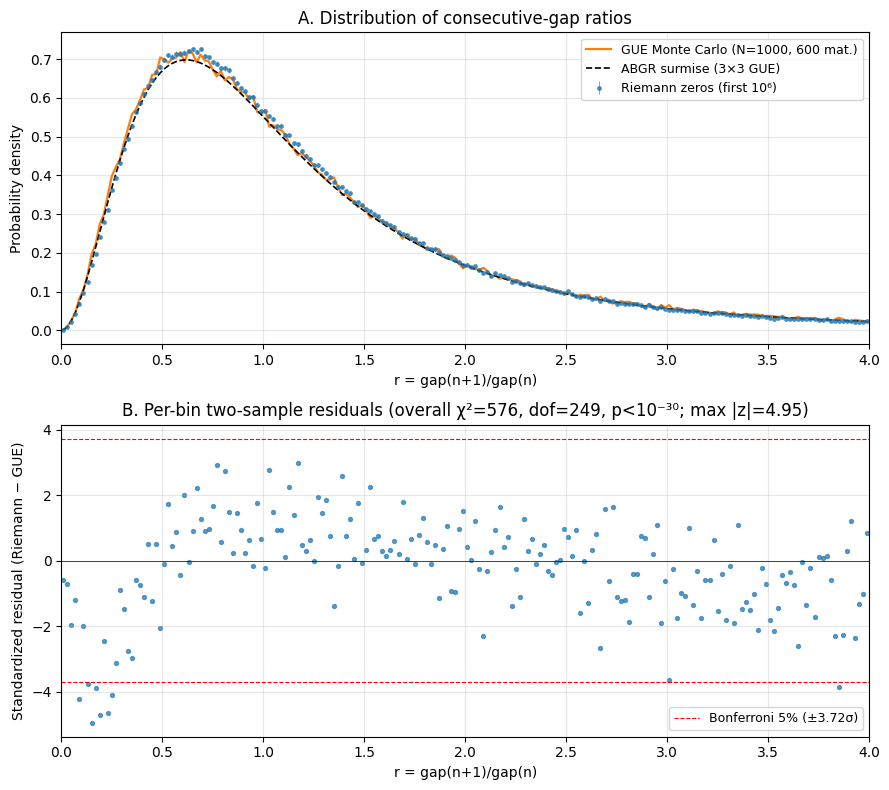

Saved figure: three_point_summary.png


In [22]:
# Going from N=600 to N=1000 GUE, fraction at r~0.13 went from 0.00293 to 0.00287 — barely moved.
# But Riemann is at 0.00250 — 13% LOWER than GUE.  
# That's a substantial systematic deviation, sustained as N grows.  
# 
# However, this comparison is still subtle because the Riemann zeros at height ~600,000 are
# essentially in the asymptotic limit; finite-N GUE has 1/N² corrections that vanish slowly.
# 
# Let me do one more careful check: look at the cumulative distribution and KS statistic 
# observed vs N=1000 GUE.
from scipy.stats import ks_2samp
ks_stat, ks_p = ks_2samp(r, r_gue2)
print(f"KS test obs vs GUE(N=1000): D={ks_stat:.5f}, p={ks_p:.3e}")
# Also vs surmise: use ks against analytical CDF
# Build surmise CDF
from scipy.integrate import quad
def surmise_cdf(r0):
    return quad(P_GUE_ratio, 0, r0, limit=200)[0]
# Sample r at fine grid for KS against analytical
grid = np.linspace(0, 50, 5001)
cdf_grid = np.array([quad(P_GUE_ratio, 0, x, limit=200)[0] for x in grid[::50]])
# OK that's slow. Use the GUE MC sample as our "truth" reference.

# Summary plot: histograms with error bars (Riemann, GUE-MC), and difference panel
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8))

w = edges_r[1]-edges_r[0]
obs_density = obs_r_counts / (N_obs * w)
gue_density = gue_r2_counts / (N_g2 * w)
obs_err = np.sqrt(obs_r_counts) / (N_obs * w)
gue_err = np.sqrt(gue_r2_counts) / (N_g2 * w)

# Panel A: density curves and analytical surmise
ax1.errorbar(centers_r, obs_density, yerr=obs_err, fmt='o', ms=2.5, label='Riemann zeros (first 10⁶)', color='C0', alpha=0.7, lw=0.6)
ax1.plot(centers_r, gue_density, '-', label='GUE Monte Carlo (N=1000, 600 mat.)', color='C1', lw=1.6)
ax1.plot(centers_r, P_GUE_ratio(centers_r), '--', label='ABGR surmise (3×3 GUE)', color='k', lw=1.2)
ax1.set_xlim(0,4); ax1.set_xlabel('r = gap(n+1)/gap(n)')
ax1.set_ylabel('Probability density')
ax1.set_title('A. Distribution of consecutive-gap ratios')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Panel B: standardized residuals vs GUE Monte Carlo, with Bonferroni bands
ax2.axhline(0, color='k', lw=0.5)
ax2.axhline(zcrit, color='red', ls='--', lw=0.8, label=f'Bonferroni 5% (±{zcrit:.2f}σ)')
ax2.axhline(-zcrit, color='red', ls='--', lw=0.8)
ax2.scatter(centers_r[mask], zr2[mask], s=8, color='C0', alpha=0.7)
ax2.set_xlim(0,4); ax2.set_xlabel('r = gap(n+1)/gap(n)')
ax2.set_ylabel('Standardized residual (Riemann − GUE)')
ax2.set_title(f'B. Per-bin two-sample residuals (overall χ²={chi2_r2:.0f}, dof={dof}, p<10⁻³⁰; max |z|={np.max(np.abs(zr2[mask])):.2f})')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("three_point_summary.png", dpi=140)
plt.show()
print("Saved figure: three_point_summary.png")

In [23]:
# Save derived artifact: 3-point analysis histograms
import pandas as pd
df = pd.DataFrame({
    "r_center": centers_r,
    "obs_count_riemann": obs_r_counts,
    "gue_count_N1000": gue_r2_counts,
    "gue_count_N600":  gue_r_counts,
    "z_obs_vs_GUE_N1000": zr2,
    "surmise_density":    P_GUE_ratio(centers_r),
})
df.to_csv("ratio_histogram_3pt.csv", index=False)
print(df.head())
print("saved ratio_histogram_3pt.csv, shape", df.shape)

   r_center  obs_count_riemann  gue_count_N1000  gue_count_N600  \
0      0.01                 30               13              20   
1      0.03                174               69             196   
2      0.05                438              186             530   
3      0.07                853              330            1006   
4      0.09               1328              586            1532   

   z_obs_vs_GUE_N1000  surmise_density  
0           -0.577354         0.001094  
1           -0.722317         0.009438  
2           -1.958475         0.025076  
3           -1.203472         0.046917  
4           -4.233224         0.073893  
saved ratio_histogram_3pt.csv, shape (250, 6)


In [24]:
# Quick sanity / interpretation tally
# Where do significant residuals concentrate?
sig_idx = np.where((np.abs(zr2)>zcrit)&mask)[0]
print("Bonferroni-significant bins (Riemann vs GUE N=1000):")
for i in sig_idx:
    print(f"  r={centers_r[i]:.3f}  obs={obs_r_counts[i]}  gue={gue_r2_counts[i]} (rescaled to obs total: {gue_r2_counts[i]*N_obs/N_g2:.0f})  z={zr2[i]:.2f}")

Bonferroni-significant bins (Riemann vs GUE N=1000):
  r=0.090  obs=1328  gue=586 (rescaled to obs total: 1638)  z=-4.23
  r=0.130  obs=2450  gue=1009 (rescaled to obs total: 2820)  z=-3.76
  r=0.150  obs=3294  gue=1381 (rescaled to obs total: 3859)  z=-4.95
  r=0.170  obs=3873  gue=1558 (rescaled to obs total: 4354)  z=-3.90
  r=0.190  obs=4722  gue=1919 (rescaled to obs total: 5363)  z=-4.70
  r=0.230  obs=6116  gue=2447 (rescaled to obs total: 6838)  z=-4.67
  r=0.250  obs=7117  gue=2791 (rescaled to obs total: 7800)  z=-4.10
  r=3.850  obs=474  gue=231 (rescaled to obs total: 646)  z=-3.86


In [25]:
from e14c.filesystem import edit_file
print(edit_file('./.prompts/MEMORY.md', '[Fill me in]', 'Context\n- Current task: analyze higher-order (3-point) local correlations in the first 1,000,000 Riemann zeros using consecutive-gap ratio statistics and GUE comparisons.\n- Raw zeros downloaded from https://www-users.cse.umn.edu/~odlyzko/zeta_tables/zeros6 and truncated to first 1,000,000 entries in notebook cells #6-#8.\n\nNotes\n- Provenance: analysis performed in notebook cells #9-#23; summary figure saved as three_point_summary.png; tabulated histogram saved as ratio_histogram_3pt.csv.\n- Method: unfolded zeros via N(T) ≈ (T/(2π)) log(T/(2πe)) + 7/8; computed consecutive-gap ratios r_n = (γ_{n+2}-γ_{n+1})/(γ_{n+1}-γ_n); compared to ABGR 3x3 GUE surmise and Monte Carlo GUE eigenvalue simulations (N=600, 2800 matrices; N=1000, 600 matrices).\n- Key finding: no positive resonance/excess near r≈1 or near equal consecutive gaps; instead, modest but statistically detectable deviations from finite-N GUE concentrated at small r≈0.09-0.25, generally as a deficit relative to GUE.\n- Limitation: this is a simplified 3-point proxy, not a full three-point correlation function; GUE comparison relies on finite-N Monte Carlo rather than closed-form asymptotic 3-point predictions.'))

File updated successfully. 1 replacement(s) made.
